In [1]:
def visualize_model_weights(model, save_dir='weight_plots', show=True):
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    os.makedirs(save_dir, exist_ok=True)

    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue

        w = weights[0]
        name = layer.name

        if w.ndim == 4:
            n_filters = w.shape[-1]
            cols = min(8, n_filters)
            rows = (n_filters + cols - 1) // cols
            fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
            axes = np.array(axes).flatten()
            for i in range(n_filters):
                kernel = w[:, :, :, i].sum(axis=-1) if w.shape[2] > 1 else w[:, :, 0, i]
                axes[i].imshow(kernel, cmap='RdBu_r', aspect='auto')
                axes[i].set_title(f'F{i}', fontsize=8)
                axes[i].axis('off')
            for i in range(n_filters, len(axes)):
                axes[i].axis('off')
            fig.suptitle(f'{name} (Conv2D) — Filter Heatmaps\n{w.shape}', fontsize=10)
            fig.tight_layout()
            fig.savefig(os.path.join(save_dir, f'{name}_heatmaps.png'), dpi=150)
            if show:
                plt.show()
            plt.close(fig)

        elif w.ndim == 3:
            fig, ax = plt.subplots(figsize=(10, 4))
            reshaped = w.reshape(-1, w.shape[-1])
            im = ax.imshow(reshaped.T, cmap='RdBu_r', aspect='auto')
            ax.set_xlabel('Kernel × Input Channels')
            ax.set_ylabel('Output Filters')
            ax.set_title(f'{name} (Conv1D) — {w.shape}')
            plt.colorbar(im, ax=ax)
            fig.tight_layout()
            fig.savefig(os.path.join(save_dir, f'{name}.png'), dpi=150)
            if show:
                plt.show()
            plt.close(fig)

        elif w.ndim == 2:
            fig, ax = plt.subplots(figsize=(10, 6))
            im = ax.imshow(w, cmap='RdBu_r', aspect='auto')
            ax.set_xlabel('Output Units')
            ax.set_ylabel('Input Units')
            ax.set_title(f'{name} (Dense) — {w.shape}')
            plt.colorbar(im, ax=ax)
            fig.tight_layout()
            fig.savefig(os.path.join(save_dir, f'{name}.png'), dpi=150)
            if show:
                plt.show()
            plt.close(fig)

        fig, ax = plt.subplots(figsize=(6, 3))
        ax.hist(w.flatten(), bins=100, color='steelblue', edgecolor='none')
        ax.set_title(f'{name} — Weight Distribution (mean={w.mean():.4f}, std={w.std():.4f})')
        ax.axvline(0, color='red', linestyle='--', alpha=0.5)
        fig.tight_layout()
        fig.savefig(os.path.join(save_dir, f'{name}_hist.png'), dpi=150)
        if show:
            plt.show()
        plt.close(fig)

def plot_all_layer_activations(model, x_sample):
    """Plot activations of ALL layers for a single sample.
    
    Args:
        model: trained keras model
        x_sample: input tensor, shape (1, timesteps, features)
    """
    # Skip input layer
    layer_outputs = []
    layer_names = []
    
    for layer in model.layers:
        if layer.__class__.__name__ == 'InputLayer':
            continue
        try:
            sub_model = tf.keras.Model(inputs=model.input, outputs=layer.output)
            act = sub_model.predict(x_sample, verbose=0)
            layer_outputs.append(act)
            layer_names.append(f"{layer.name} ({layer.__class__.__name__})")
        except Exception as e:
            print(f"Skipping {layer.name}: {e}")
    
    n = len(layer_outputs)
    fig, axes = plt.subplots(n, 1, figsize=(16, 2.5 * n))
    if n == 1:
        axes = [axes]
    
    for ax, act, name in zip(axes, layer_outputs, layer_names):
        act = np.squeeze(act, axis=0)  # remove batch dim
        
        if act.ndim == 3:
            # (H, W, C) or similar — flatten to 2D
            h, w, c = act.shape
            act_2d = act.reshape(h * w, c)
            im = ax.imshow(act_2d.T, aspect='auto', interpolation='nearest', cmap='viridis')
            ax.set_ylabel('Channel')
            ax.set_xlabel('Spatial (flattened)')
            plt.colorbar(im, ax=ax, fraction=0.02)
        elif act.ndim == 2:
            # (time, channels)
            im = ax.imshow(act.T, aspect='auto', interpolation='nearest', cmap='viridis')
            ax.set_ylabel('Channel')
            ax.set_xlabel('Time')
            plt.colorbar(im, ax=ax, fraction=0.02)
        elif act.ndim == 1:
            # dense / output
            ax.bar(range(len(act)), act, width=1.0, edgecolor='none')
            ax.set_xlabel('Unit')
            ax.set_ylabel('Activation')
            ax.set_xlim(-0.5, len(act) - 0.5)
        elif act.ndim == 0:
            ax.text(0.5, 0.5, f"Scalar: {float(act):.6f}", 
                    transform=ax.transAxes, ha='center', va='center', fontsize=14)
        else:
            # 4D+ — take mean over extra dims
            while act.ndim > 2:
                act = act.mean(axis=0)
            im = ax.imshow(act.T if act.ndim == 2 else act[np.newaxis, :], 
                          aspect='auto', cmap='viridis')
            plt.colorbar(im, ax=ax, fraction=0.02)
        
        # Add stats to title
        act_flat = np.squeeze(act).flatten()
        stats = f"min={act_flat.min():.3f} max={act_flat.max():.3f} mean={act_flat.mean():.3f} std={act_flat.std():.3f}"
        ax.set_title(f"{name}  shape={np.squeeze(act).shape}  [{stats}]", fontsize=9)
    
    plt.tight_layout()
    plt.savefig("all_layer_activations.png", dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Plotted {n} layers. Saved all_layer_activations.png")


# Usage:
#plot_all_layer_activations(cnn_model, x)



In [2]:
import tensorflow as tf
from tensorflow.data import TFRecordDataset 
import numpy as np
import os
import matplotlib.pyplot as plt
from common import fast_gpu_map,SAMPLERATE,feature_description

from model import build_1d_cnn_model
import common


BATCH_SIZE=1
recordfile="/data/test_subset/filtered_poly_data_64962.tfrecord"
model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/checkpoints/guitarmidi_epoch338_valAcc0.9572_valPrec0.6728_valRecall0.7037.h5"#
#model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/guitarmidi.weights.h5"

cnn_model=build_1d_cnn_model(BATCH_SIZE,common.INPUT_SHAPE,37,training=False)# common.OUTPUT_DIM_NOTES,training=False)
cnn_model.load_weights(model_weights)
for var in cnn_model.trainable_variables:
    var_id = getattr(var, 'path', var.name)
    if "freq_compress_conv2d" in var_id:
        print(var_id)

#visualize_model_weights(cnn_model)

dataset=TFRecordDataset(recordfile)
def parse_example(example_proto):
    return tf.io.parse_single_example(example_proto, feature_description)
# Parse the dataset
dataset = dataset.map(parse_example)#.shuffle(buffer_size=10000,reshuffle_each_iteration=True)
dataset=dataset.map(lambda x: fast_gpu_map(x,training=False)).batch(BATCH_SIZE,drop_remainder=True).take(1000).prefetch(tf.data.AUTOTUNE)
#dataset=dataset.map(lambda path: fast_gpu_map(path, training=False)).take(100).prefetch(tf.data.AUTOTUNE)
#dataset = dataset.shuffle(BATCH_SIZE * 2).map(lambda path: fast_gpu_map(path, training=False), num_parallel_calls=tf.data.AUTOTUNE)
labels_true_all=[]
labels_pred_all=[]
total_tp=0
total_fp=0
total_fn=0

#Get the 7th tuple of the dataset (audio, label) and run a prediction

audio,label=None,None
element_idx=20
for idx, (audio_batch, label_batch) in enumerate(dataset):
    if idx == element_idx:
        x = audio_batch
        y_true = label_batch
        break

#plot_all_layer_activations(cnn_model, x)
y_pred = cnn_model.predict(x)

for i in range(len(y_true)):
    true_notes = np.where(y_true[i] > 0.5)[0]
    pred_raw = y_pred[i]
    
    # Show top 10 highest predictions
    top10 = np.argsort(pred_raw)[-10:][::-1]
    
    print(f"\n--- Sample {i} ---")
    print(f"True notes: {true_notes}")
    print(f"Top 10 predictions:")
    for idx in top10:
        print(f"  note {idx}: {pred_raw[idx]:.4f} {'✓' if idx in true_notes else ''}")
    
    # Show prediction stats
    print(f"Max: {pred_raw.max():.4f}, Min: {pred_raw.min():.4f}, "
          f"Mean: {pred_raw.mean():.4f}, >0.5: {(pred_raw > 0.5).sum()}")
    # Prediction standard deviation
    print(f"Std Dev: {pred_raw.std():.4f}")

for audio,label in dataset:
    # print("Audio shape:", audio.shape)
    pred=cnn_model.predict(audio,verbose=0)
    # print("Pred shape:", pred.shape)
    # print("Label shape:", label.shape)
    label=label.numpy()#.flatten()
    label=label[:,:37]
    pred=pred#.flatten()
    # print("flat Pred shape:", pred.shape)
    # print("flat Label shape:", label.shape)
    labels_true_all.append(label)
    labels_pred_all.append(pred)
    thresh=0.5
    label_active = label#[:88] # Assuming 88 notes
    pred_active = pred#[ :88]
    total_tp += np.sum((label_active == 1) & (pred_active > thresh))
    #total_tp+=np.sum((label==1) & (pred>thresh))
    total_fp+=np.sum((label_active==0)&(pred_active>thresh))
    total_fn+=np.sum((label_active==1)&(pred_active<=thresh))



print("Total True Positives:", total_tp)
print("Total False Positives:", total_fp)
print("Total False Negatives:", total_fn)
precision=total_tp/(total_tp+total_fp+1e-8)
recall=total_tp/(total_tp+total_fn+1e-8)
print("Precision:", precision)
print("Recall:", recall)


I0000 00:00:1775246246.406150 1586732 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775246246.445227 1586732 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775246247.315875 1586732 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Image height:  148


W0000 00:00:1775246248.349255 1586732 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1775246248.354117 1586732 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1775246248.493584 1586732 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1641 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0a


Before string split: (1, 148, 64), max_x=148.0
freq_compress_conv2d/kernel
freq_compress_conv2d/bias


I0000 00:00:1775246249.619821 1586915 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144
I0000 00:00:1775246250.043878 1586846 service.cc:153] XLA service 0x7b078c04a910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775246250.043908 1586846 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5080, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.14.0)
I0000 00:00:1775246250.067381 1586846 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775246250.240127 1586846 cuda_dnn.cc:461] Loaded cuDNN version 91400


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


I0000 00:00:1775246251.984822 1586846 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



--- Sample 0 ---
True notes: [21 25 28 33]
Top 10 predictions:
  note 21: 0.7580 ✓
  note 24: 0.4671 
  note 20: 0.4365 
  note 34: 0.3753 
  note 25: 0.3666 ✓
  note 22: 0.3416 
  note 26: 0.2944 
  note 29: 0.1399 
  note 33: 0.1235 ✓
  note 14: 0.0897 
Max: 0.7580, Min: 0.0010, Mean: 0.1147, >0.5: 1
Std Dev: 0.1697
Total True Positives: 2165
Total False Positives: 1128
Total False Negatives: 1555
Precision: 0.6574552080150092
Recall: 0.5819892473102635


In [3]:
print("Length of labels_true_all:", len(labels_true_all))
labels_true=np.concatenate(labels_true_all,axis=0)
labels_pred=np.concatenate(labels_pred_all,axis=0)
labels_pred=(labels_pred>0.5).astype(np.float32)
print("Shape of labels true:",labels_true.shape)
#compute recall
tp=np.sum((labels_true==1) & (labels_pred==1),axis=0)

fp=np.sum((labels_true==0)&(labels_pred==1),axis=0)
fn=np.sum((labels_true==1)&(labels_pred==0),axis=0)
print("Shape of tp",tp.shape)

precision=tp/(tp+fp+1e-8)
print("precision:", precision)
recall=tp/(tp+fn+1e-8)
print("recall:", recall)
print("True Positives:", tp)
print("False Positives:", fp)

Length of labels_true_all: 1000
Shape of labels true: (1000, 37)
Shape of tp (37,)
precision: [0.88235294 0.17777778 0.74       0.65909091 0.35294118 0.575
 0.52380952 0.66101695 0.66863905 0.48913043 0.78873239 0.45454545
 0.75117371 0.48484848 0.5625     0.75657895 0.5        0.72384937
 0.7375     0.55675676 0.64912281 0.54216867 0.79746835 0.56666667
 0.38655462 0.52       0.44       0.69473684 0.5        0.33333333
 0.         0.875      0.66666667 0.99999999 0.         0.
 0.        ]
recall: [0.77586207 0.57142857 0.59677419 0.63043478 1.         0.79310345
 0.39285714 0.70481928 0.64942529 0.68181818 0.73684211 0.41666667
 0.82474227 0.36363636 0.61016949 0.79310345 0.61764706 0.79357798
 0.36875    0.68666667 0.76027397 0.34615385 0.76829268 0.20731707
 0.52272727 0.14130435 0.34375    0.53225806 0.04444444 0.5
 0.         0.21212121 0.10526316 0.01470588 0.         0.
 0.        ]
True Positives: [ 90   8  37  58   6  46  11 117 113  45 224  15 160  32  72 230  21 173
  59 10

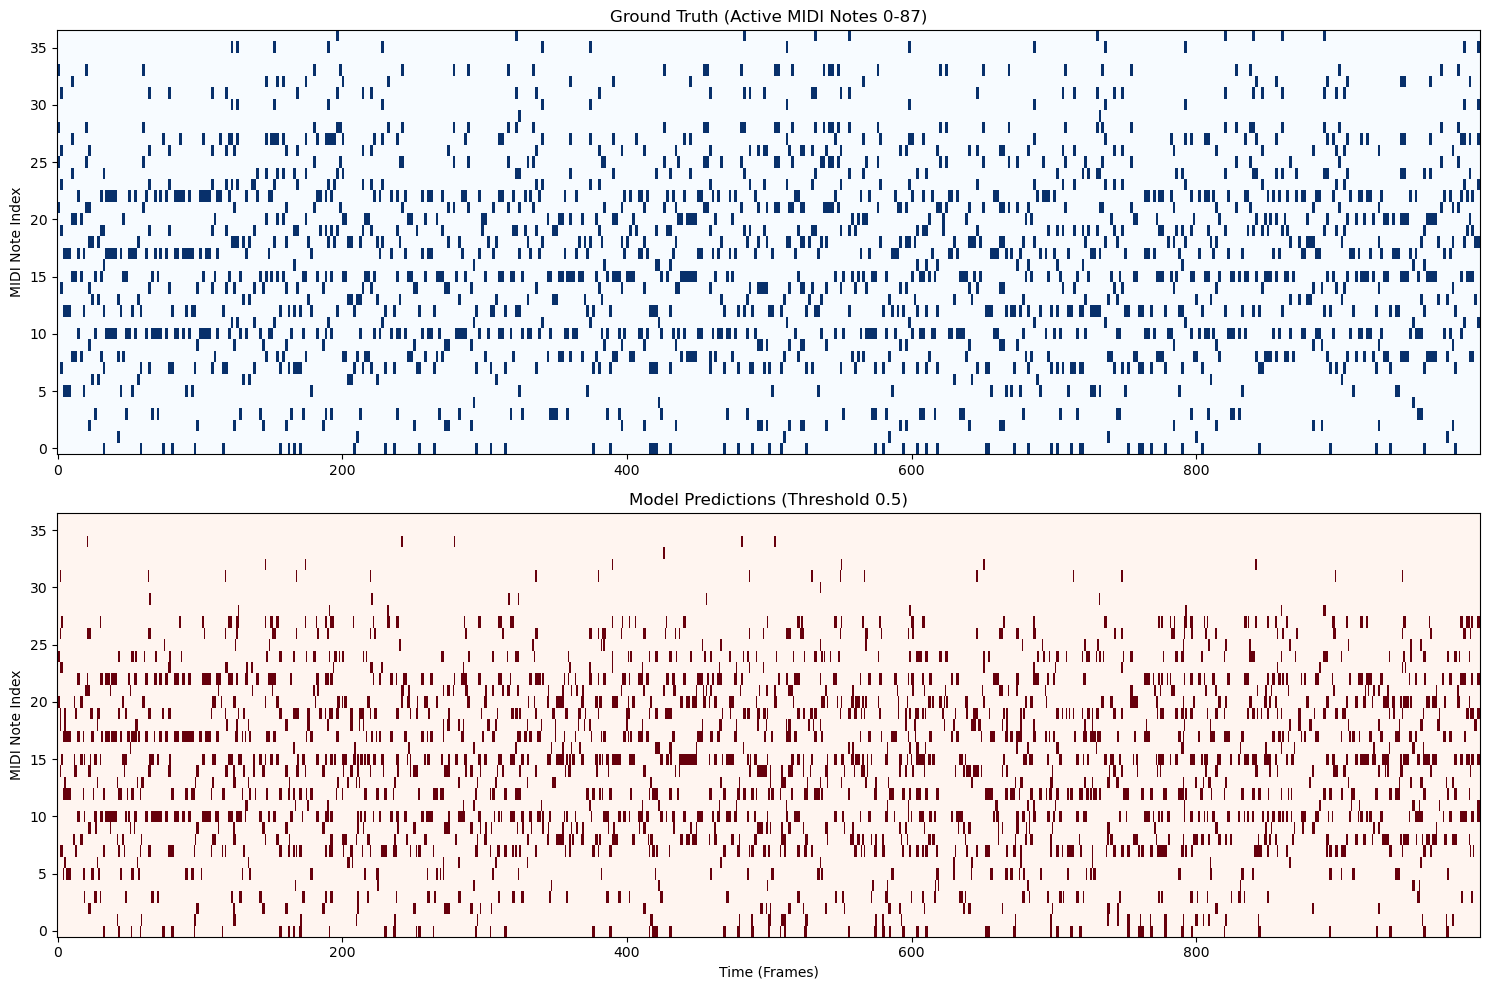

: 

In [ ]:
# Convert lists to single arrays
all_true = np.concatenate(labels_true_all, axis=0)[:, :88]
all_pred = np.concatenate(labels_pred_all, axis=0)[:, :88]

# Binary threshold for the plot
all_pred_bin = (all_pred > 0.5).astype(np.float32)

plt.figure(figsize=(15, 10))

# Plot Ground Truth (Blue)
plt.subplot(2, 1, 1)
plt.imshow(all_true.T, aspect='auto', origin='lower', cmap='Blues', interpolation='nearest')
plt.title("Ground Truth (Active MIDI Notes 0-87)")
plt.ylabel("MIDI Note Index")

# Plot Predictions (Red)
plt.subplot(2, 1, 2)
plt.imshow(all_pred_bin.T, aspect='auto', origin='lower', cmap='Reds', interpolation='nearest')
plt.title("Model Predictions (Threshold 0.5)")
plt.ylabel("MIDI Note Index")
plt.xlabel("Time (Frames)")

plt.tight_layout()
plt.show()